# Electronics Sales Data Analysis
### End-to-end project: Data Cleaning -> Feature Engineering -> Exploratory Data Analysis -> Visualization

This notebook covers the full workflow of analyzing an electronics sales dataset (49,316 orders, Jan-Dec 2025), from raw data inspection to uncovering the key business insight: **the ratio of shipping cost to product price** is the real driver behind unprofitable orders.

## 1. Data Loading & Inspection
Load the raw CSV file and get a first look at its shape, column types, and general structure.

In [36]:
import pandas as pd

df = pd.read_csv('Elec-sales-analysis-project.csv')
print(df.shape)
df.info()

(49317, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49317 entries, 0 to 49316
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            49317 non-null  object 
 1   Order_Date          49317 non-null  object 
 2   Product_ID          49317 non-null  object 
 3   SKU                 49317 non-null  object 
 4   Category            49317 non-null  object 
 5   Subcategory         49317 non-null  object 
 6   Brand               49317 non-null  object 
 7   Model               49317 non-null  object 
 8   Base_Price          49317 non-null  float64
 9   Discount            49316 non-null  float64
 10  Final_Price_each    49316 non-null  float64
 11  Units_Sold          49316 non-null  float64
 12  Revenue             49316 non-null  float64
 13  Cost                49316 non-null  float64
 14  Shipping_Cost       49316 non-null  float64
 15  Profit              49316 non-null  float

## 2. Data Cleaning

### 2.1 Removing corrupted rows
Check for rows with a large number of missing values across many columns (likely corrupted or incomplete records), and remove any row where an essential column like `Customer_ID` is missing.

In [37]:
# Check rows with a large number of missing values (more than 15 empty columns, for example)
missing_per_row = df.isnull().sum(axis=1)
print(df[missing_per_row > 15])

# Once confirmed as a corrupted row, drop it
df = df.dropna(subset=['Customer_ID'])  # Customer_ID is essential; if missing, the row is invalid
print(df.shape)  # Should now be one row less than before

       Order_ID  Order_Date Product_ID               SKU     Category  \
49316  O1009433  2025-12-26     P00288  P00288-ATR-ROU-2  Electronics   

      Subcategory    Brand      Model  Base_Price  Discount  ...  \
49316      Router  Atronix  ATR-ROU-2      521.49       NaN  ...   

       Review_Count  Seller_ID  Customer_ID  Customer_Age_Group  \
49316           NaN        NaN          NaN                 NaN   

       Customer_Gender  Region  Shipping_Method  Delivery_Days  Return_Flag  \
49316              NaN     NaN              NaN            NaN          NaN   

      Return_Reason  
49316           NaN  

[1 rows x 28 columns]
(49316, 28)


### 2.2 Fixing data types
Convert `Order_Date` to an actual datetime object, and make sure all numeric columns are stored as numbers (not text), coercing any invalid values to NaN.

In [38]:
# Convert Order_Date to an actual date type
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Make sure numeric columns are stored as numbers
numeric_cols = ['Base_Price','Discount','Final_Price_each','Units_Sold',
                 'Revenue','Cost','Shipping_Cost','Profit','Profit_Margin',
                 'Rating','Review_Count','Delivery_Days']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

### 2.3 Handling logically-empty values
`Return_Reason` is empty whenever an order was never returned — this is not missing data, it's a valid piece of information, so we fill it with an explicit label instead of leaving it as NaN.

In [39]:
df['Return_Reason'] = df['Return_Reason'].fillna('Not Returned')

### 2.4 Sanity checks on the numbers
Run a statistical summary and check for any values that break basic business logic (negative revenue, zero units sold, or a profit margin outside a reasonable -100% to 100% range).

In [40]:
print(df[numeric_cols].describe())

# Make sure there is no negative Revenue or Units_Sold = 0
print("Negative Revenue:", (df['Revenue'] < 0).sum())
print("Units_Sold = 0:", (df['Units_Sold'] == 0).sum())
print("Unusual Profit_Margin (outside -1 to 1):", ((df['Profit_Margin'] < -1) | (df['Profit_Margin'] > 1)).sum())

        Base_Price      Discount  Final_Price_each    Units_Sold  \
count  49316.00000  49316.000000      49316.000000  49316.000000   
mean     359.28691      0.033615        347.259564      1.257117   
std      219.45941      0.064023        213.971281      0.654139   
min       21.25000      0.000000         14.870000      1.000000   
25%      194.38000      0.000000        185.140000      1.000000   
50%      342.56000      0.000000        324.150000      1.000000   
75%      489.26000      0.050000        479.200000      1.000000   
max     1079.44000      0.300000       1079.440000      5.000000   

            Revenue          Cost  Shipping_Cost        Profit  Profit_Margin  \
count  49316.000000  49316.000000   49316.000000  49316.000000   49316.000000   
mean     437.218522    316.376643      11.482886    109.358993       0.212423   
std      382.449596    280.172488       7.870822    123.574545       0.155100   
min       14.870000     11.720000       0.000000   -275.350000 

### 2.5 Investigating the outliers
22 rows show a profit margin outside the -100% to 100% range. Let's inspect them and verify the profit formula (`Revenue - Cost - Shipping_Cost`) is being calculated correctly.

In [41]:
outliers = df[(df['Profit_Margin'] < -1) | (df['Profit_Margin'] > 1)].copy()
print(outliers[['Order_ID','Base_Price','Discount','Final_Price_each',
                 'Revenue','Cost','Profit','Profit_Margin']])

       Order_ID  Base_Price  Discount  Final_Price_each  Revenue   Cost  \
5918   O1033093       31.30      0.15             26.60    26.60  23.28   
9661   O1023192       24.35      0.15             20.70    20.70  18.52   
11329  O1042932       23.88      0.20             19.10    19.10  17.61   
12082  O1021695       21.70      0.00             21.70    21.70  17.11   
12291  O1036898       21.70      0.00             21.70    21.70  16.95   
23309  O1031705       24.35      0.10             21.92    21.92  20.43   
25932  O1004228       23.92      0.00             23.92    23.92  20.00   
27938  O1008458       30.71      0.30             21.50    21.50  25.84   
29366  O1011910       21.25      0.10             19.12    19.12  17.58   
30962  O1008630       23.92      0.00             23.92    23.92  18.12   
31086  O1029512       23.92      0.30             16.74    16.74  19.88   
32299  O1030744       21.25      0.00             21.25    21.25  16.25   
33278  O1044429       24.

In [42]:
outliers = df[(df['Profit_Margin'] < -1) | (df['Profit_Margin'] > 1)].copy()
print(outliers[['Order_ID','Revenue','Cost','Shipping_Cost','Profit','Profit_Margin']])

# Verify the formula manually
outliers['calculated_profit'] = outliers['Revenue'] - outliers['Cost'] - outliers['Shipping_Cost']
print(outliers[['Profit','calculated_profit']])

       Order_ID  Revenue   Cost  Shipping_Cost  Profit  Profit_Margin
5918   O1033093    26.60  23.28           30.0  -26.68        -1.0030
9661   O1023192    20.70  18.52           30.0  -27.82        -1.3440
11329  O1042932    19.10  17.61           30.0  -28.51        -1.4927
12082  O1021695    21.70  17.11           30.0  -25.41        -1.1710
12291  O1036898    21.70  16.95           30.0  -25.25        -1.1636
23309  O1031705    21.92  20.43           30.0  -28.51        -1.3006
25932  O1004228    23.92  20.00           30.0  -26.08        -1.0903
27938  O1008458    21.50  25.84           20.0  -24.34        -1.1321
29366  O1011910    19.12  17.58           30.0  -28.46        -1.4885
30962  O1008630    23.92  18.12           30.0  -24.20        -1.0117
31086  O1029512    16.74  19.88           20.0  -23.14        -1.3823
32299  O1030744    21.25  16.25           30.0  -25.00        -1.1765
33278  O1044429    20.70  15.35           30.0  -24.65        -1.1908
33284  O1041216    2

**Finding:** the formula is correct — `Profit` matches `calculated_profit` exactly. The real cause is that these are low-priced products (around $20-30) shipped via expensive methods, so the shipping cost alone equals or exceeds the product's value. This is a genuine business pattern, not a data error — so we keep these rows and flag them instead of removing them.

### 2.6 Flagging loss-making orders

In [43]:
df['Loss_Making_Order'] = df['Profit'] < 0
print("Number of loss-making orders:", df['Loss_Making_Order'].sum())
print("Their share of total orders:", (df['Loss_Making_Order'].sum() / len(df) * 100).round(2), "%")

Number of loss-making orders: 3583
Their share of total orders: 7.27 %


## 3. Feature Engineering

### 3.1 Extracting date components
Break the single `Order_Date` column into multiple useful features for time-based analysis.

In [44]:
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Month_Name'] = df['Order_Date'].dt.strftime('%B')
df['Order_Week'] = df['Order_Date'].dt.isocalendar().week
df['Order_DayOfWeek'] = df['Order_Date'].dt.day_name()
df['Order_Quarter'] = df['Order_Date'].dt.quarter

### 3.2 Categorizing profit margin
Turn the raw profit margin number into a readable category using a custom function applied row-by-row.

In [45]:
def categorize_profit(margin):
    if margin < 0:
        return 'Loss'
    elif margin < 0.15:
        return 'Low Margin'
    elif margin < 0.30:
        return 'Medium Margin'
    else:
        return 'High Margin'

df['Profit_Category'] = df['Profit_Margin'].apply(categorize_profit)
print(df['Profit_Category'].value_counts())

Profit_Category
Medium Margin    21845
High Margin      14735
Low Margin        9154
Loss              3582
Name: count, dtype: int64


### 3.3 Total cost (product + shipping)

In [46]:
df['Total_Cost'] = df['Cost'] + df['Shipping_Cost']

### 3.4 Order value tiers
Bucket continuous revenue values into readable tiers for easier segmentation.

In [47]:
df['Order_Value_Tier'] = pd.cut(df['Revenue'], 
                                   bins=[0, 100, 300, 600, float('inf')],
                                   labels=['Low (<100)', 'Medium (100-300)', 'High (300-600)', 'Premium (600+)'])
print(df['Order_Value_Tier'].value_counts())

Order_Value_Tier
High (300-600)      19233
Medium (100-300)    14545
Premium (600+)       9866
Low (<100)           5672
Name: count, dtype: int64


### 3.5 Checkpoint: save the cleaned dataset

In [48]:
df.to_csv('cleaned_sales_data.csv', index=False)
print("Saved! Shape:", df.shape)
print("Current columns:", df.columns.tolist())

Saved! Shape: (49316, 37)
Current columns: ['Order_ID', 'Order_Date', 'Product_ID', 'SKU', 'Category', 'Subcategory', 'Brand', 'Model', 'Base_Price', 'Discount', 'Final_Price_each', 'Units_Sold', 'Revenue', 'Cost', 'Shipping_Cost', 'Profit', 'Profit_Margin', 'Rating', 'Review_Count', 'Seller_ID', 'Customer_ID', 'Customer_Age_Group', 'Customer_Gender', 'Region', 'Shipping_Method', 'Delivery_Days', 'Return_Flag', 'Return_Reason', 'Loss_Making_Order', 'Order_Month', 'Order_Month_Name', 'Order_Week', 'Order_DayOfWeek', 'Order_Quarter', 'Profit_Category', 'Total_Cost', 'Order_Value_Tier']


## 4. Exploratory Data Analysis (EDA)

Reload the cleaned checkpoint (in case this section is run in a fresh session) and start answering the key business questions.

In [49]:
import pandas as pd
df = pd.read_csv('cleaned_sales_data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])  # dates are stored as text in CSV, so we must convert again

### 4.1 Profitability by product category

In [50]:
category_analysis = df.groupby('Subcategory').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Orders_Count=('Order_ID', 'count'),
    Loss_Orders=('Loss_Making_Order', 'sum')
).sort_values('Total_Profit', ascending=False)

print(category_analysis)

                   Total_Revenue  Total_Profit  Avg_Profit_Margin  \
Subcategory                                                         
TV                    3219419.31     850987.24           0.258623   
Laptop                2668810.02     702667.92           0.255709   
Tablet                1797108.68     462013.05           0.247396   
Monitor               1679817.51     431689.02           0.236062   
Smartphone            1665327.10     422752.93           0.240595   
Camera                1635011.22     413321.07           0.240137   
Smartwatch            1489855.01     370224.96           0.228704   
Charger               1062858.71     255226.65           0.193225   
SSD                   1007704.70     242601.40           0.193637   
Keyboard              1012154.01     238258.81           0.196237   
Memory Card            975071.30     230140.52           0.203004   
Mouse                  902917.52     210907.38           0.205040   
Bluetooth Speaker      889616.56  

**Chart:** Total profit by product category, highlighting the weakest performer (Headphones).

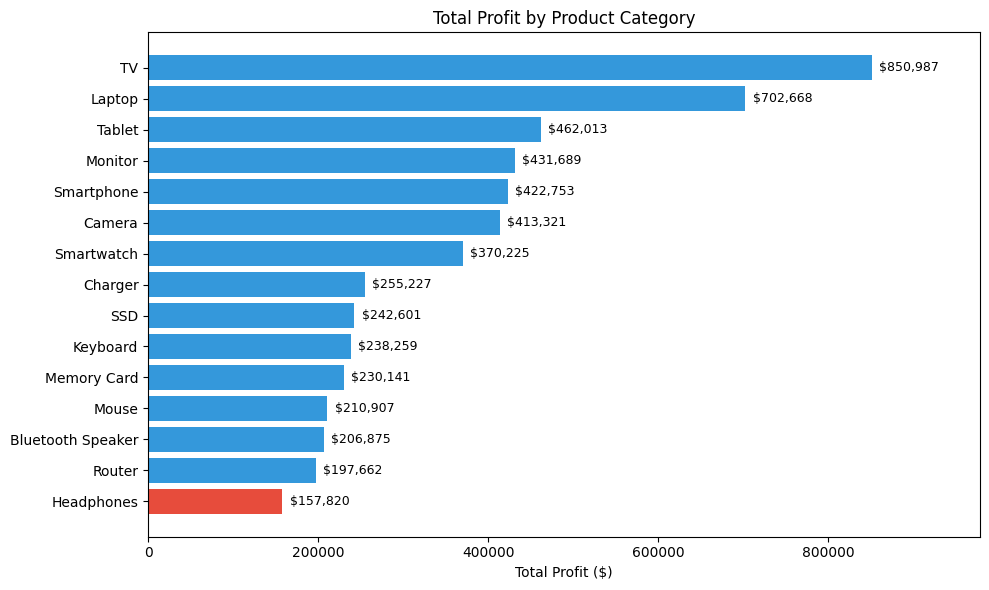

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
cat_sorted = category_analysis.sort_values('Total_Profit')
colors = ['#e74c3c' if v == cat_sorted['Total_Profit'].min() else '#3498db' for v in cat_sorted['Total_Profit']]
bars = plt.barh(cat_sorted.index, cat_sorted['Total_Profit'], color=colors)

# إضافة القيم جنب كل بار
for bar, value in zip(bars, cat_sorted['Total_Profit']):
    plt.text(
        bar.get_width() + (cat_sorted['Total_Profit'].max() * 0.01),  
        bar.get_y() + bar.get_height()/2,                             
        f'${value:,.0f}',                                             
        va='center', fontsize=9
    )

plt.xlabel('Total Profit ($)')
plt.title('Total Profit by Product Category')
plt.xlim(0, cat_sorted['Total_Profit'].max() * 1.15)  
plt.tight_layout()
plt.show()

### 4.2 Performance by region

In [52]:
region_analysis = df.groupby('Region').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Orders_Count=('Order_ID', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Return_Rate=('Return_Flag', 'mean')
).sort_values('Total_Revenue', ascending=False)

print(region_analysis)

         Total_Revenue  Total_Profit  Avg_Profit_Margin  Orders_Count  \
Region                                                                  
North       5406915.26    1358396.68           0.214172         12264   
South       5313390.60    1328771.60           0.214177         12248   
East        4390732.08    1090880.38           0.209414         10004   
West        4267943.38    1067327.99           0.212083          9838   
Central     2182887.32     547771.45           0.210508          4962   

         Avg_Rating  Return_Rate  
Region                            
North      4.169767     0.049331  
South      4.176852     0.050131  
East       4.176456     0.049180  
West       4.162511     0.051230  
Central    4.161191     0.044740  


**Chart:** Revenue vs. loss rate by region — do any regions show a higher share of loss-making orders?

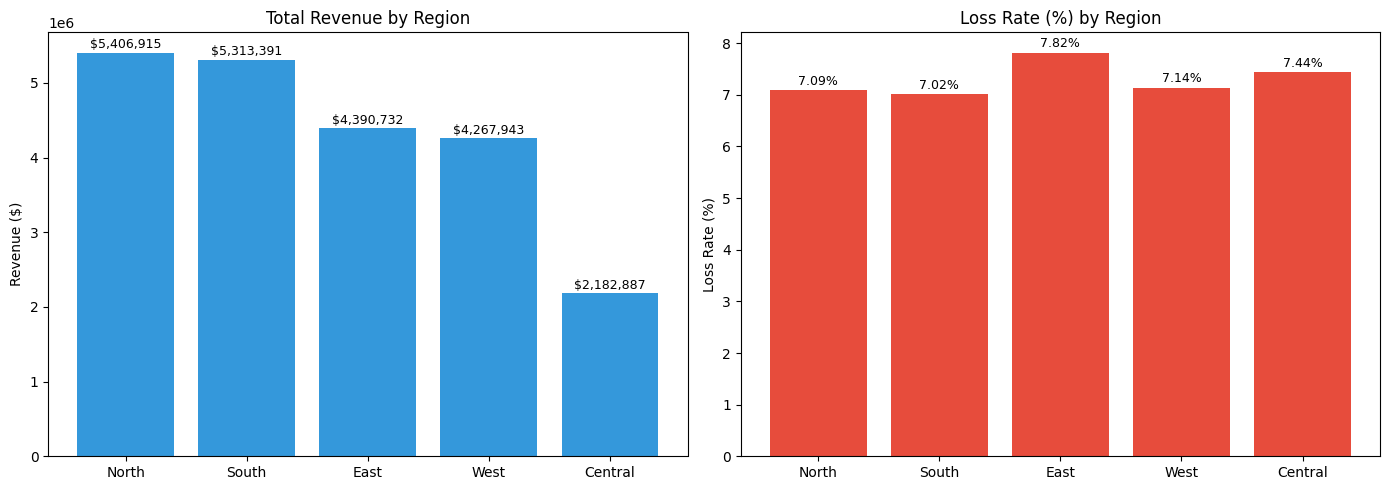

         Total_Revenue  Loss_Rate  Loss_Rate_%
Region                                        
North       5406915.26   0.070939         7.09
South       5313390.60   0.070216         7.02
East        4390732.08   0.078169         7.82
West        4267943.38   0.071356         7.14
Central     2182887.32   0.074365         7.44


In [53]:
region_loss = df.groupby('Region').agg(
    Total_Revenue=('Revenue', 'sum'),
    Loss_Rate=('Loss_Making_Order', 'mean')
).sort_values('Total_Revenue', ascending=False)
region_loss['Loss_Rate_%'] = (region_loss['Loss_Rate'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

bars1 = axes[0].bar(region_loss.index, region_loss['Total_Revenue'], color='#3498db')
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue ($)')
for bar, value in zip(bars1, region_loss['Total_Revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (region_loss['Total_Revenue'].max()*0.01),
                 f'${value:,.0f}', ha='center', fontsize=9)

bars2 = axes[1].bar(region_loss.index, region_loss['Loss_Rate_%'], color='#e74c3c')
axes[1].set_title('Loss Rate (%) by Region')
axes[1].set_ylabel('Loss Rate (%)')
for bar, value in zip(bars2, region_loss['Loss_Rate_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{value}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(region_loss)

**Finding:** loss rate is nearly flat across all regions — this confirms the loss issue is product-driven, not geography-driven.

### 4.3 Shipping method analysis

In [54]:
shipping_analysis = df.groupby('Shipping_Method').agg(
    Avg_Shipping_Cost=('Shipping_Cost', 'mean'),
    Avg_Base_Price=('Base_Price', 'mean'),
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Loss_Orders=('Loss_Making_Order', 'sum'),
    Total_Orders=('Order_ID', 'count')
).sort_values('Avg_Profit_Margin')

shipping_analysis['Loss_Rate_%'] = (shipping_analysis['Loss_Orders'] / shipping_analysis['Total_Orders'] * 100).round(2)
print(shipping_analysis)

                 Avg_Shipping_Cost  Avg_Base_Price  Avg_Profit_Margin  \
Shipping_Method                                                         
Same-Day                 11.520756      353.102285           0.208510   
Two-Day                  11.487285      358.768751           0.211512   
Standard                 11.489907      359.367487           0.212264   
Expedited                11.449421      360.940240           0.214520   

                 Loss_Orders  Total_Orders  Loss_Rate_%  
Shipping_Method                                          
Same-Day                 192          2433         7.89  
Two-Day                  545          7275         7.49  
Standard                2170         29673         7.31  
Expedited                676          9935         6.80  


**Chart:** Loss rate by shipping method — spoiler: they're all very close, which disproves the initial hypothesis that shipping *method* alone causes losses.

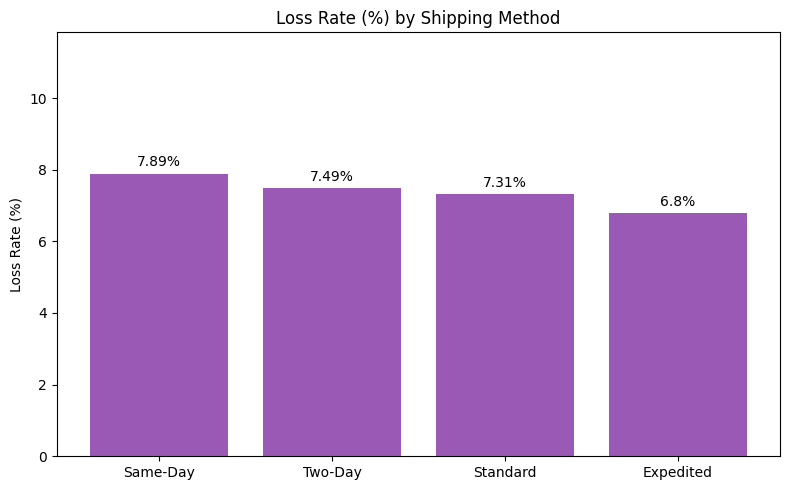

In [55]:
plt.figure(figsize=(8,5))
ship_sorted = shipping_analysis.sort_values('Loss_Rate_%', ascending=False)
plt.bar(ship_sorted.index, ship_sorted['Loss_Rate_%'], color='#9b59b6')
plt.ylabel('Loss Rate (%)')
plt.title('Loss Rate (%) by Shipping Method')
plt.ylim(0, max(ship_sorted['Loss_Rate_%'])*1.5)
for i, v in enumerate(ship_sorted['Loss_Rate_%']):
    plt.text(i, v + 0.2, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

### 4.4 The real driver: shipping cost as a percentage of product price

Since the shipping *method* doesn't explain the losses, we test a more precise metric: how much of the product's price is eaten up by shipping cost.

In [56]:
# Ratio of shipping cost to product price (high shipping cost on a cheap product = risk)
df['Shipping_to_Price_Ratio'] = df['Shipping_Cost'] / df['Base_Price']

print(df['Shipping_to_Price_Ratio'].describe())

# Compare the ratio between loss-making and healthy orders
print(df.groupby('Loss_Making_Order')['Shipping_to_Price_Ratio'].mean())

count    49316.000000
mean         0.063882
std          0.111597
min          0.000000
25%          0.015539
50%          0.032089
75%          0.061700
max          1.411765
Name: Shipping_to_Price_Ratio, dtype: float64
Loss_Making_Order
False    0.045054
True     0.304211
Name: Shipping_to_Price_Ratio, dtype: float64


**Finding:** loss-making orders have a shipping-to-price ratio roughly **7x higher** than healthy orders (30.4% vs. 4.5%). This is the key discovery of the whole analysis.

In [57]:
# Bucket the ratio into risk tiers and check the loss rate in each tier
df['Shipping_Ratio_Tier'] = pd.cut(df['Shipping_to_Price_Ratio'],
                                     bins=[0, 0.05, 0.10, 0.20, float('inf')],
                                     labels=['<5%', '5-10%', '10-20%', '>20%'])

risk_table = df.groupby('Shipping_Ratio_Tier', observed=True).agg(
    Total_Orders=('Order_ID', 'count'),
    Loss_Orders=('Loss_Making_Order', 'sum')
)
risk_table['Loss_Rate_%'] = (risk_table['Loss_Orders'] / risk_table['Total_Orders'] * 100).round(2)
print(risk_table)

                     Total_Orders  Loss_Orders  Loss_Rate_%
Shipping_Ratio_Tier                                        
<5%                         23625          563         2.38
5-10%                        8653          360         4.16
10-20%                       4044          440        10.88
>20%                         3249         2090        64.33


**Chart:** the headline chart of this entire project — loss rate jumps to over 64% once shipping cost exceeds 20% of the product's price.

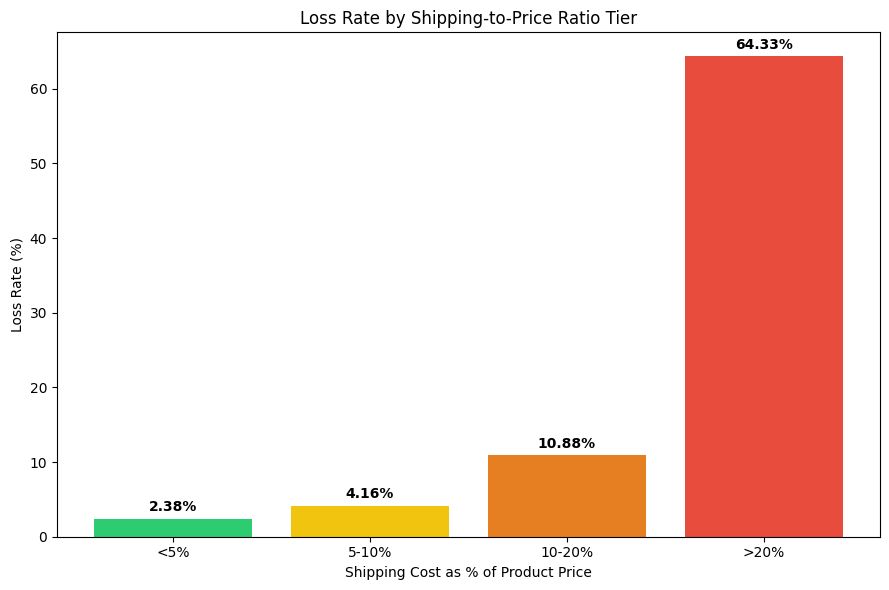

In [58]:
plt.figure(figsize=(9,6))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = plt.bar(risk_table.index.astype(str), risk_table['Loss_Rate_%'], color=colors)
plt.ylabel('Loss Rate (%)')
plt.xlabel('Shipping Cost as % of Product Price')
plt.title('Loss Rate by Shipping-to-Price Ratio Tier')
for bar, val in zip(bars, risk_table['Loss_Rate_%']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Revenue by customer age group

In [59]:
age_analysis = df.groupby('Customer_Age_Group').agg(
    Total_Revenue=('Revenue', 'sum'),
    Avg_Order_Value=('Revenue', 'mean'),
    Return_Rate=('Return_Flag', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Orders_Count=('Order_ID', 'count')
).sort_values('Total_Revenue', ascending=False)

print(age_analysis)

                    Total_Revenue  Avg_Order_Value  Return_Rate  Avg_Rating  \
Customer_Age_Group                                                            
25-34                  7539784.57       437.723342     0.053179    4.168312   
35-44                  5372981.73       433.724712     0.050936    4.172284   
45-54                  3223052.93       444.191418     0.043964    4.174558   
18-24                  2608326.51       438.595344     0.045737    4.167108   
55-64                  1743852.86       436.836889     0.042585    4.175847   
65+                    1073870.04       428.177847     0.051435    4.165941   

                    Orders_Count  
Customer_Age_Group                
25-34                      17225  
35-44                      12388  
45-54                       7256  
18-24                       5947  
55-64                       3992  
65+                         2508  


**Chart:** revenue by age group — the 25-34 segment clearly leads.

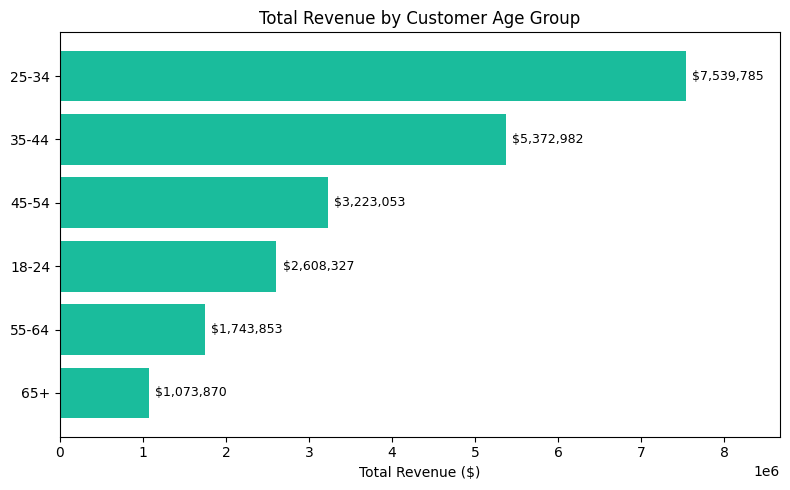

In [60]:
plt.figure(figsize=(8,5))
age_sorted = age_analysis.sort_values('Total_Revenue')
bars = plt.barh(age_sorted.index, age_sorted['Total_Revenue'], color='#1abc9c')
for bar, value in zip(bars, age_sorted['Total_Revenue']):
    plt.text(bar.get_width() + (age_sorted['Total_Revenue'].max()*0.01),
             bar.get_y() + bar.get_height()/2,
             f'${value:,.0f}', va='center', fontsize=9)
plt.xlabel('Total Revenue ($)')
plt.title('Total Revenue by Customer Age Group')
plt.xlim(0, age_sorted['Total_Revenue'].max() * 1.15)
plt.tight_layout()
plt.show()

### 4.6 Rating vs. return likelihood

In [61]:
rating_return = df.groupby('Return_Flag').agg(
    Avg_Rating=('Rating', 'mean'),
    Orders_Count=('Order_ID', 'count')
)
print(rating_return)

print(df[df['Return_Flag']==1]['Return_Reason'].value_counts())

             Avg_Rating  Orders_Count
Return_Flag                          
0.0            4.170482         46879
1.0            4.172331          2437
Return_Reason
Damaged in Shipping    509
Changed Mind           492
Not as Described       491
Wrong Item             486
Defective              459
Name: count, dtype: int64


**Chart:** average rating for returned vs. non-returned orders (practically identical), and the breakdown of return reasons (evenly distributed across all 5 categories).

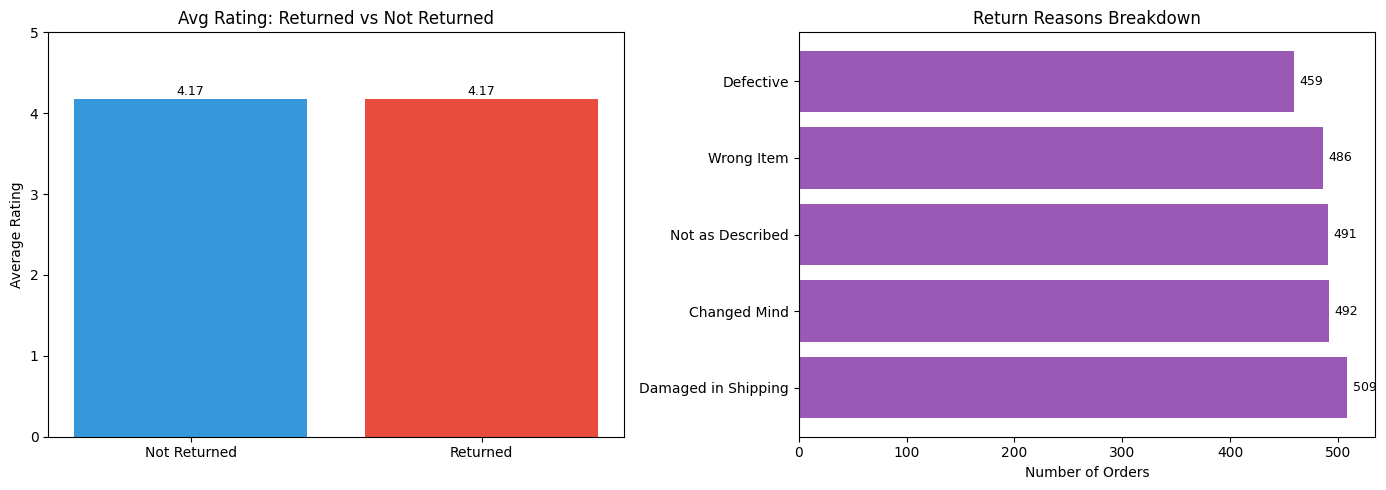

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

labels = ['Not Returned', 'Returned']
bars1 = axes[0].bar(labels, rating_return['Avg_Rating'], color=['#3498db', '#e74c3c'])
axes[0].set_ylim(0, 5)
axes[0].set_ylabel('Average Rating')
axes[0].set_title('Avg Rating: Returned vs Not Returned')
for bar, value in zip(bars1, rating_return['Avg_Rating']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{value:.2f}', ha='center', fontsize=9)

return_reasons = df[df['Return_Flag']==1]['Return_Reason'].value_counts()
bars2 = axes[1].barh(return_reasons.index, return_reasons.values, color='#9b59b6')
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('Return Reasons Breakdown')
for bar, value in zip(bars2, return_reasons.values):
    axes[1].text(bar.get_width() + (return_reasons.values.max()*0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'{value}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.7 Monthly revenue trend

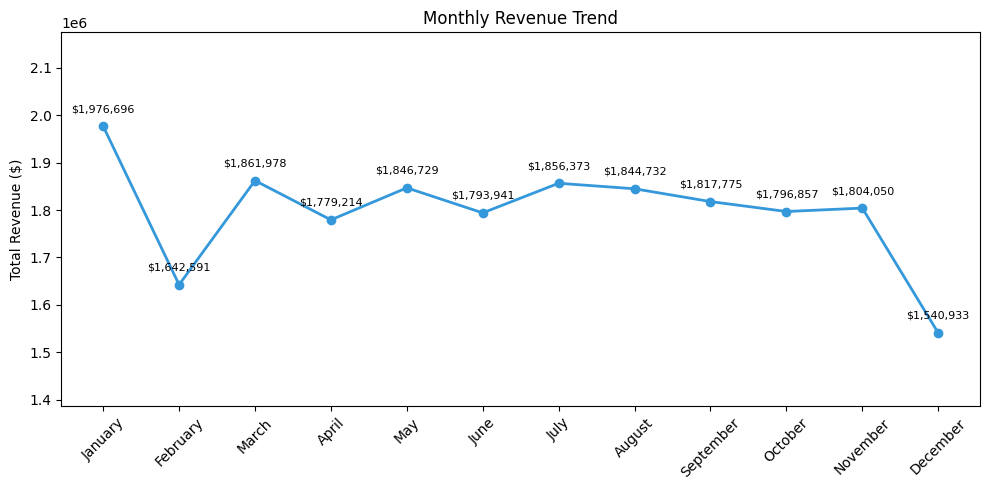

In [63]:
monthly_trend = df.groupby(['Order_Month','Order_Month_Name']).agg(
    Total_Revenue=('Revenue', 'sum')
).reset_index().sort_values('Order_Month')

plt.figure(figsize=(10,5))
plt.plot(monthly_trend['Order_Month_Name'], monthly_trend['Total_Revenue'], marker='o', color='#3498db', linewidth=2)
for x, y in zip(monthly_trend['Order_Month_Name'], monthly_trend['Total_Revenue']):
    plt.text(x, y + (monthly_trend['Total_Revenue'].max()*0.015),
             f'${y:,.0f}', ha='center', fontsize=8)
plt.xticks(rotation=45)
plt.ylabel('Total Revenue ($)')
plt.title('Monthly Revenue Trend')
plt.ylim(monthly_trend['Total_Revenue'].min()*0.9, monthly_trend['Total_Revenue'].max()*1.1)
plt.tight_layout()
plt.show()

## 5. Save Final Dataset
Save the fully cleaned and feature-engineered dataset — this is the file used as the Power BI data source.

In [64]:
df.to_csv('final_dashboard_data.csv', index=False)
print("Saved! Final shape:", df.shape)

Saved! Final shape: (49316, 39)


## 6. Summary of Key Findings

1. **Shipping-to-price ratio is the real driver of losses** — when shipping exceeds 20% of a product's price, the loss rate jumps to 64.3% (vs. 2.4% when shipping is under 5% of price).
2. **Headphones** is the weakest category by margin (11.8% avg profit margin, 21.5% loss rate).
3. **No meaningful profitability gap between regions** — the issue is product-driven, not geographic.
4. **The 25-34 age group** drives the largest share of revenue through repeat purchases.
5. **No correlation between product rating and return likelihood** — return reasons are evenly distributed across 5 categories.